Loading Dataset...

TRAIN DATASET
                filename    label                                  filepath
0     0005_000000020.jpg     flip     data/training/flip/0005_000000020.jpg
1     0038_000000009.jpg     flip     data/training/flip/0038_000000009.jpg
2     0011_000000019.jpg     flip     data/training/flip/0011_000000019.jpg
3     0062_000000023.jpg     flip     data/training/flip/0062_000000023.jpg
4     0038_000000021.jpg     flip     data/training/flip/0038_000000021.jpg
...                  ...      ...                                       ...
2387  0049_000000021.jpg  notflip  data/training/notflip/0049_000000021.jpg
2388  0011_000000028.jpg  notflip  data/training/notflip/0011_000000028.jpg
2389  0005_000000011.jpg  notflip  data/training/notflip/0005_000000011.jpg
2390  0038_000000004.jpg  notflip  data/training/notflip/0038_000000004.jpg
2391  0011_000000014.jpg  notflip  data/training/notflip/0011_000000014.jpg

[2392 rows x 3 columns]

TEST DATASET
               

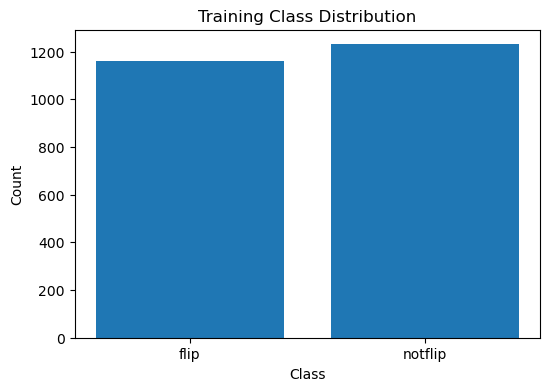

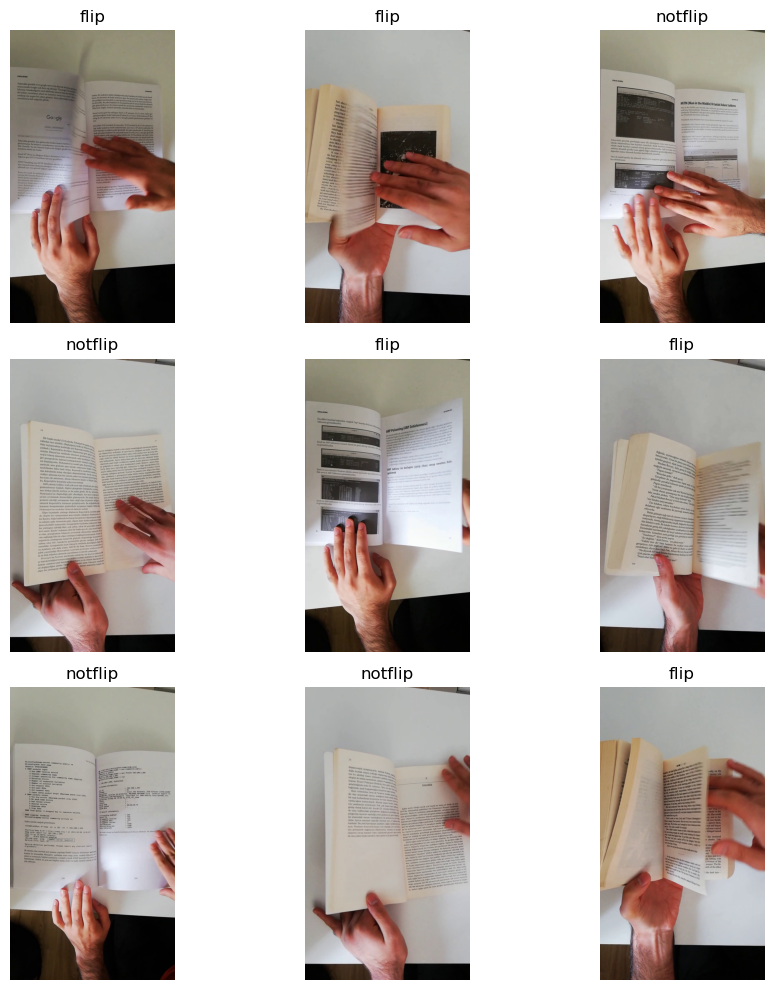

In [25]:
import os
import random
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import pandas as pd

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")
TRAIN_DIR = "data/training"
TEST_DIR = "data/testing"

def get_dataset_info(folder):

    image_info = []
    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)
        if not os.path.isdir(label_path):
            continue
        for filename in os.listdir(label_path):
            if filename.lower().endswith(IMAGE_EXTENSIONS):
                filepath = os.path.join(label_path, filename)
                image_info.append(
                    {
                        "filename": filename,
                        "label": label,
                        "filepath": filepath
                    }
                )
    return pd.DataFrame(image_info)


def check_image_sizes(df):

    widths = []
    heights = []
    corrupted = []

    for path in df["filepath"]:

        img = cv2.imread(path) ## saves the image data as a numpy array

        if img is None:
            corrupted.append(path)
            continue

        h, w = img.shape[:2] ## extracts the width and height of the image

        widths.append(w)
        heights.append(h)

    print("=" * 60)
    print("IMAGE SIZE SUMMARY")
    print("=" * 60)

    print(f"Minimum Width : {min(widths)}")
    print(f"Maximum Width : {max(widths)}")

    print(f"Minimum Height: {min(heights)}")
    print(f"Maximum Height: {max(heights)}")

    print(f"Unique Sizes  : {len(set(zip(widths, heights)))}")

    print(f"Corrupted Images: {len(corrupted)}")

    if corrupted:
        print("\nCorrupted Files:")
        for c in corrupted:
            print(c)


def plot_class_distribution(df, title):

    counts = Counter(df["label"])

    plt.figure(figsize=(6,4))
    plt.bar(counts.keys(), counts.values())

    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")

    plt.show()


def display_random_images(df, n=9):

    sample = df.sample(n=min(n, len(df)), random_state=42)

    plt.figure(figsize=(10,10))

    for i, (_, row) in enumerate(sample.iterrows()):

        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():

    print("=" * 60)
    print("Loading Dataset...")
    print("=" * 60)

    train_df = get_dataset_info(TRAIN_DIR)
    test_df = get_dataset_info(TEST_DIR)

    print("\nTRAIN DATASET")
    print(train_df)

    print("\nTEST DATASET")
    print(test_df)

    print("\n")

    print("=" * 60)
    print("Dataset Statistics")
    print("=" * 60)

    print(f"Training Images : {len(train_df)}")
    print(f"Testing Images  : {len(test_df)}")

    print("\nTraining Class Distribution")

    print(train_df["label"].value_counts())

    print("\nTesting Class Distribution")

    print(test_df["label"].value_counts())

    check_image_sizes(train_df)

    plot_class_distribution(train_df, "Training Class Distribution")

    display_random_images(train_df)


if __name__ == "__main__":
    main()

In [26]:
import os
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit # split based on group, which is video ID in this case

from PIL import Image # used to open the images
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader 
# Dataset defines how images are loaded, and Data Loaders packages images into batches

from torchvision import transforms # provides image-processing operations

TRAIN_DIR = "data/training"

train_transform = transforms.Compose([

    transforms.Resize((224,224)), # every image becomes 224 pixels by 224 pixels

    transforms.RandomRotation(5), # rotates the image by up to approximately ±5 degrees

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ), # randomly changes brightness and contrast

    transforms.ToTensor(), # change the PIL image to numerical tensors for PyTorch processing

    transforms.Normalize(
        mean=[0.485,0.456,0.406], # normalizes the RGB channels
        std=[0.229,0.224,0.225]
    )
])


val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


def create_dataframe(folder):

    data=[]

    label_map = {
        "notflip":0,
        "flip":1
    }


    for label_name in os.listdir(folder):

    # Ignore hidden folders like .ipynb_checkpoints
        if label_name.startswith("."):
            continue

        label_path = os.path.join(
            folder,
            label_name
        )

        if not os.path.isdir(label_path):
            continue


        label=label_map[label_name]


        for filename in os.listdir(label_path):

            if filename.endswith(
                (".jpg",".jpeg",".png")
            ):

                filepath=os.path.join(
                    label_path,
                    filename
                )


                # Example:
                # Video1_00000010.jpg

                video_id = filename.split("_")[0]


                data.append({
                    "filepath":filepath,
                    "label":label,
                    "video_id":video_id
                })


    return pd.DataFrame(data)




# ==========================================================
# Split by Video ID
# ==========================================================

def train_validation_split(df):
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df["label"]
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

    return train_df, val_df



# ==========================================================
# PyTorch Dataset
# ==========================================================


class MonReaderDataset(Dataset):
    
    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df=dataframe
        self.transform=transform

    def __len__(self): # tells how many images are in the dataset
        return len(self.df)

    def __getitem__(self,index):
        row=self.df.iloc[index]
        image=Image.open(
            row["filepath"]
        ).convert("RGB") # opens the image and convert it to RGB

        label=torch.tensor(
            row["label"],
            dtype=torch.long
        )

        if self.transform:
            image=self.transform(image)
            
        return image,label




# ==========================================================
# Create DataLoaders
# ==========================================================


def get_dataloaders():


    df=create_dataframe(TRAIN_DIR)

    print("\nDataset size:")
    print(len(df))

    train_df,val_df=train_validation_split(df)

    print("\nTraining samples:")
    print(len(train_df))


    print("\nValidation samples:")
    print(len(val_df))


    train_dataset=MonReaderDataset(
        train_df,
        transform=train_transform
    ) # dataset using the training images and apply the training transformations
    
    val_dataset=MonReaderDataset(
        val_df,
        transform=val_transform
    )


    train_loader=DataLoader(

        train_dataset,
        batch_size=32,
        shuffle=True, # training images are randomly shuffled each epoch
        num_workers=0
    ) # packages individual images into batches.


    val_loader=DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False, # you don't need to randomly shuffle validation data
        num_workers=0
    )


    return train_loader,val_loader




# ==========================================================
# Test
# ==========================================================


if __name__=="__main__":


    train_loader,val_loader=get_dataloaders()

    images,labels=next(
        iter(train_loader)
    ) # first batch of training images and their labels.
    
    print("\nImage batch:")
    print(images.shape)

    print("\nLabels:")
    print(labels)


Dataset size:
2392

Training samples:
1913

Validation samples:
479

Image batch:
torch.Size([32, 3, 224, 224])

Labels:
tensor([0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        1, 0, 0, 1, 1, 0, 1, 0])


In [27]:
import torch
import torch.nn as nn ## neural network
import timm ## library containing many pretrained computer-vision models.


class MonReaderModel(nn.Module):

    def __init__(self):

        super().__init__()

        # Load pretrained EfficientNet-B0
        self.model = timm.create_model(
            "efficientnet_b0", 
            pretrained=True
        )

        # Get number of input features
        in_features = self.model.classifier.in_features # How many features are coming into EfficientNet's final classifier

        # Replace EfficientNet's original classifier with your own
        self.model.classifier = nn.Sequential(

            nn.Dropout(0.3), # adds dropout with probability 0.3. During training, approximately 30% of the inputs to this layer are randomly dropped.
            nn.Linear(
                in_features,
                2 # two logits
            )
        )

    def forward(self,x):

        return self.model(x)



if __name__ == "__main__":


    model=MonReaderModel()
    dummy=torch.randn(
        4,
        3,
        224,
        224
    )
    # 4     → batch size
    # 3     → RGB channels
    # 224   → image height
    # 224   → image width

    output=model(dummy)
    print(output.shape)

torch.Size([4, 2])


In [28]:
import torch
import torch.nn as nn
from torch.optim import AdamW #AdamW is the optimizer.
# The optimizer is responsible for changing the model's weights based on the error calculated during training.

from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm #tqdm gives you a progress bar while training

DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # determines whether PyTorch should use a GPU or CPU
EPOCHS = 10 # one epoch pass through the entire training dataset.
LR = 1e-4 # learning rate controls how aggressively the optimizer changes the model's weights



def validate(
    model,
    loader,
    criterion
):
    model.eval() # I am evaluating the model, not training it
    losses=[]
    predictions=[]
    targets=[]
    
    with torch.no_grad(): # Disable gradient calculations
        
        for images,labels in loader:
            images=images.to(DEVICE) # Move images to the device
            labels=labels.to(DEVICE) # Move images to the device - Images need to be on the same device as the model.
            outputs=model(images) # sends the images through your EfficientNet.
            loss=criterion(
                outputs,
                labels
            )

            losses.append(
                loss.item() # .item() converts the PyTorch tensor into a normal Python number.
            )

            preds=torch.argmax(
                outputs,
                dim=1
            ) # Convert model scores into predictions

            predictions.extend(
                preds.cpu().numpy() # store the prediction
            )

            targets.extend(
                labels.cpu().numpy() # store the actual labels
            )

    f1=f1_score(
        targets,
        predictions # calculate the F1-score
    )

    acc=accuracy_score(
        targets,
        predictions # calculate the accuracy score
    )

    return (
        sum(losses)/len(losses),
        f1,
        acc
    )



# ===============================
# Training
# ===============================


def train():
    train_loader,val_loader=get_dataloaders()
    model=MonReaderModel()
    model=model.to(DEVICE)

    criterion=nn.CrossEntropyLoss()
    optimizer=AdamW(
        model.parameters(),
        lr=LR
    )
    best_f1=0

    for epoch in range(EPOCHS):
        model.train()
        running_loss=0

        loop=tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{EPOCHS}"
        ) # this creates the progress bar

        for images,labels in loop: # get batches from your training DataLoader.
            images=images.to(DEVICE)
            labels=labels.to(DEVICE)
            optimizer.zero_grad() # clears old gradient
            outputs=model(images) # make the predictions
            loss=criterion( # calculate training loss
                outputs,
                labels
            )

            loss.backward() # Calculate which weights contributed to the error
            # calculates the gradients of the loss with respect to the model's trainable parameters
            optimizer.step() # uses those gradients to modify the model's weights.
            running_loss += loss.item() # accumulates the loss

            loop.set_postfix(
                loss=loss.item()
            ) # updates the progress bar

        train_loss=(
            running_loss /
            len(train_loader)
        ) # calculates the average training loss 

        val_loss,val_f1,val_acc=validate(
            model,
            val_loader,
            criterion
        )

        print("\n")
        print("="*50)
        print(
            f"Epoch {epoch+1}"
        )

        print(
            f"Train Loss: {train_loss:.4f}"
        )

        print(
            f"Validation Loss: {val_loss:.4f}"
        )

        print(
            f"Validation Accuracy: {val_acc:.4f}"
        )

        print(
            f"Validation F1: {val_f1:.4f}"
        )

        print("="*50)



        # Save best model

        if val_f1 > best_f1:
            best_f1=val_f1
            patience_counter = 0
            torch.save(
                model.state_dict(),
                "best_monreader_model.pth"
            )

            print(
                "Saved best model!"
            )
        else:
            patience_counter += 1

            print(
            f"No improvement in F1. "
            f"Patience: {patience_counter}/3"
            )

            if patience_counter >= 3:
                print("Early stopping!")
                break

if __name__=="__main__":

    train()


Dataset size:
2392

Training samples:
1913

Validation samples:
479


Epoch 1/10: 100%|██████████████████████████████████████████████████████████| 60/60 [08:17<00:00,  8.29s/it, loss=0.0605]




Epoch 1
Train Loss: 0.3592
Validation Loss: 0.0712
Validation Accuracy: 0.9875
Validation F1: 0.9870
Saved best model!


Epoch 2/10: 100%|██████████████████████████████████████████████████████████| 60/60 [08:06<00:00,  8.11s/it, loss=0.0147]




Epoch 2
Train Loss: 0.0461
Validation Loss: 0.0202
Validation Accuracy: 0.9979
Validation F1: 0.9979
Saved best model!


...



Epoch 4
Train Loss: 0.0156
Validation Loss: 0.0070
Validation Accuracy: 1.0000
Validation F1: 1.0000
No improvement in F1. Patience: 1/3


Epoch 5/10: 100%|██████████████████████████████████████████████████████████| 60/60 [07:11<00:00,  7.20s/it, loss=0.0155]




Epoch 5
Train Loss: 0.0091
Validation Loss: 0.0042
Validation Accuracy: 1.0000
Validation F1: 1.0000
No improvement in F1. Patience: 2/3


Epoch 6/10: 100%|██████████████████████████████████████████████████████████| 60/60 [05:54<00:00,  5.91s/it, loss=0.0745]




Epoch 6
Train Loss: 0.0049
Validation Loss: 0.0031
Validation Accuracy: 1.0000
Validation F1: 1.0000
No improvement in F1. Patience: 3/3
Early stopping!


In [29]:
import torch

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def evaluate():

    _, val_loader = get_dataloaders() # get the validation data-loader
    model = MonReaderModel()

    # load the trained model
    model.load_state_dict(
        torch.load(
            "best_monreader_model.pth",
            map_location=DEVICE # tells PyTorch where to load the model
        )
    )

    model.to(DEVICE)
    model.eval()
    predictions = []
    actual = []


    with torch.no_grad(): # disable gradient calculations
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images) # make predictions

            preds = torch.argmax(
                outputs,
                dim=1
            ) # Convert the outputs into class predictions

            predictions.extend(
                preds.cpu().numpy()
            )

            actual.extend(
                labels.cpu().numpy()
            )

    print("="*50)

    print("Evaluation Results")

    print("="*50)


    print(
        "Accuracy:",
        accuracy_score(
            actual,
            predictions
        )
    )

    print(
        "Precision:",
        precision_score(
            actual,
            predictions
        )
    )

    print(
        "Recall:",
        recall_score(
            actual,
            predictions
        )
    )

    print(
        "F1 Score:",
        f1_score(
            actual,
            predictions
        )
    )

    print("\nConfusion Matrix")

    print(
        confusion_matrix(
            actual,
            predictions
        )
    )


    print("\nClassification Report")

    print(
        classification_report(
            actual,
            predictions,
            target_names=[
                "notflip",
                "flip"
            ]
        )
    )



if __name__=="__main__":

    evaluate()


Dataset size:
2392

Training samples:
1913

Validation samples:
479
Evaluation Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix
[[246   0]
 [  0 233]]

Classification Report
              precision    recall  f1-score   support

     notflip       1.00      1.00      1.00       246
        flip       1.00      1.00      1.00       233

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



In [30]:
import torch

from PIL import Image # This allows you to open the image file

from torchvision import transforms # Import image transformations

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"



transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ), # resize the image

    transforms.ToTensor(), # PIL image is converted into a PyTorch tensor.

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]

    ) # normalizes the RGB channels

])


def predict(image_path):


    model = MonReaderModel()

    # load the trained weights
    model.load_state_dict(
        torch.load(
            "best_monreader_model.pth",
            map_location=DEVICE
        )
    )

    model.to(DEVICE)

    model.eval()
    
    image = Image.open(
        image_path
    ).convert("RGB") # opens the image and converts it to RGB.

    image = transform(
        image
    ) # transform the image
    
    image = image.unsqueeze(0) # add a batch dimension and now the model sees one image in a batch
    image=image.to(DEVICE)

    with torch.no_grad(): # disable gradient calculations

        output=model(image)

        probability=torch.softmax(
            output,
            dim=1
        ) # convert logits to probabilities that add up to 1

        prediction=torch.argmax(
            probability,
            dim=1
        ) # find the most likely class

    classes = [
        "notflip",
        "flip"
    ]


    print(
        "Prediction:",
        classes[prediction.item()] # prediction.item() converts the PyTorch tensor into a regular number
    )


    print(
        "Confidence:",
        probability[0][prediction].item()
    )




if __name__=="__main__":


    predict(
        "data/training/flip/0001_000000010.jpg"
    )

Prediction: flip
Confidence: 0.9973133206367493
